# Backpropagation in Multilayer Neural Networks

While we will primarily be working with high-level, abstract toolkits like Keras in this course, understanding how backpropagation works is absolutely essential to using neural networks. 

In this exercise, we will build our own backpropagation algorithm - working through each step, to ensure that we can follow it.

Just like in Lab 1, we'll be working with the MNIST dataset. We will load it and plot an example:

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

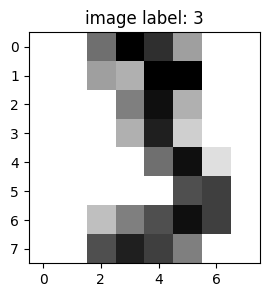

In [2]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);

### Preprocessing

Of course, we need to split our data into training and testing sets before we use it, just the same as in Lab 1:

In [3]:
from sklearn.model_selection import train_test_split

data = np.asarray(digits.data, dtype='float32')
target = np.asarray(digits.target, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.15, random_state=37)

# Numpy Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using numpy. Here are the objectives:

- Implement the softmax function $\sigma(\mathbf{x})_i = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}}$;
- Implement the negative log likelihood function $NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}$;
- Train a logistic regression model on the MNIST dataset;
- Evaluate the model on the training and testing sets.

Before we get there, let's write a function that one-hot encodes the class labels:

In [4]:
def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

In [5]:
one_hot(n_classes=10, y=3)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [6]:
one_hot(n_classes=10, y=[0, 4, 9, 1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

### The softmax function

Now we will implement the softmax function. Recall that the softmax function is defined as follows:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

This is implemented for you using numpy - we want to be able to apply the softmax function to a batch of samples at once, so we will use numpy's vectorized operations to do so.

Our method also handles _stability issues_ that can occur when the values in `X` are very large. We will subtract the maximum value from each row of `X` to avoid overflow in the exponentiation. This isn't part of the softmax function itself, but it's a useful trick to know about.

In [7]:
def softmax(X):
    X_max = np.max(X, axis=-1, keepdims=True)
    exp = np.exp(X - X_max) # Subtract the max to avoid overflow in the exponentiation
    return exp / np.sum(exp, axis=-1, keepdims=True)


Let's make sure that this works one vector at a time (and check that the components sum to one):

In [8]:
print(softmax([10, 2, -3]))

[9.99662391e-01 3.35349373e-04 2.25956630e-06]


When we are using our model to make predictions, we will want to be able to make predictions for multiple samples at once.
Let's make sure that our implementation of softmax works for a batch of samples:

In [9]:
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


Probabilities should sum to 1:

In [10]:
print(np.sum(softmax([10, 2, -3])))

1.0


In [11]:
print("softmax of 2 vectors:")
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

softmax of 2 vectors:
[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


The sum of probabilities for each input vector of logits should some to 1:

In [12]:
print(np.sum(softmax(X), axis=1))

[1. 1.]


Now we will implement a function that, given the true one-hot encoded class `Y_true` and some predicted probabilities `Y_pred`, returns the negative log likelihood.

Recall that the negative log likelihood is defined as follows:

$$
NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}
$$

For example, if we have $y_{true} = [1, 0, 0]$ and $y_{pred} = [0.99, 0.01, 0]$, then the negative log likelihood is $- \log(0.99) \approx 0.01$.

In [13]:
def nll(Y_true, Y_pred):
    Y_true = np.asarray(Y_true)
    Y_pred = np.asarray(Y_pred)

    # Ensure Y_pred doesn't have zero probabilities to avoid log(0)
    Y_pred = np.clip(Y_pred, 1e-15, 1 - 1e-15)

    # Calculate negative log likelihood
    loss = -np.sum(Y_true * np.log(Y_pred))
    return loss

# Make sure that it works for a simple sample at a time
print(nll([1, 0, 0], [.99, 0.01, 0]))

0.01005033585350145


We should see a very high value for this negative log likelihood, since the model is very confident that the third class is the correct one, but the true class is the first one:

In [14]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

4.605170185988091


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [15]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = np.array([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = np.array([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

0.010050335853503449


Now that we have our softmax and negative log likelihood functions, we can implement a logistic regression model. 
In this section, we have built the model for you, but you will need to complete a few key parts.

**YOUR TURN:**

1. Implement the `forward` method of the `LogisticRegression` class. This method should take in a batch of samples `X` and return the predicted probabilities for each class. You should use the softmax function that we implemented earlier.
2. Implement the `loss` method of the `LogisticRegression` class. This method take in the samples `X` and the true values `y` and return the average negative log likelihood of the predictions.

In [16]:
class LogisticRegression:

    def __init__(self, input_size, output_size):
        # Initialize the weights and biases with random numbers
        self.W = np.random.uniform(size=(input_size, output_size),
                                   high=0.1, low=-0.1)
        self.b = np.random.uniform(size=output_size,
                                   high=0.1, low=-0.1)
        
        # Store the input size and output size
        self.output_size = output_size
        self.input_size = input_size
        
    def forward(self, X):
        # Compute the linear combination of the input and weights
        Z = np.dot(X, self.W) + self.b
        return softmax(Z)
    
    def predict(self, X):
        # Return the most probable class for each sample in X
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)
            
    def loss(self, X, y):
        # Compute the negative log likelihood over the data provided
        y_onehot = one_hot(self.output_size, y.astype(int))
        y_pred = self.forward(X)
        return nll(y_onehot, y_pred)

    def grad_loss(self, X, y_true, y_pred):
        # Compute the gradient of the loss with respect to W and b for a single sample (X, y_true)
        # y_pred is the output of the forward pass
    
        # Gradient with respect to weights
        grad_W = np.dot(X.T, (y_pred - y_true))
    
        # Gradient with respect to biases
        grad_b = np.sum(y_pred - y_true, axis=0)
    
        return grad_W, grad_b
    
# Raise an exception if you try to run this cell without having implemented the LogisticRegression class
model = LogisticRegression(input_size=64, output_size=10)
try:
    assert(model.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(model.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the LogisticRegression class.")

In [17]:
# Build a model and test its forward inference
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
lr = LogisticRegression(n_features, n_classes)

We can evaluate the model on an example, visualizing the prediction probabilities:

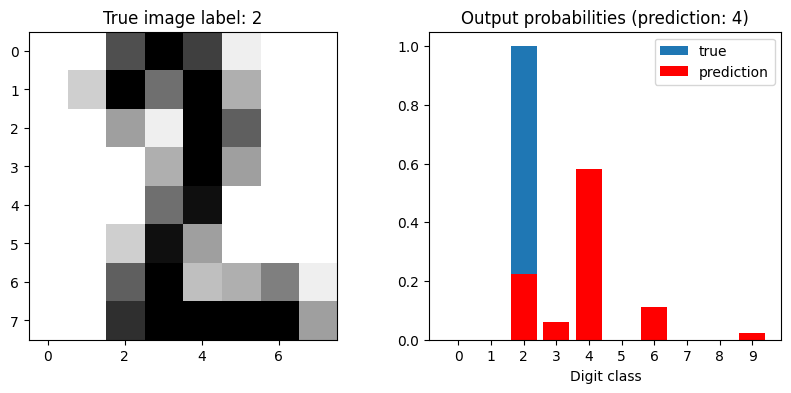

In [18]:
def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    ax0.imshow(X_test[sample_idx:sample_idx+1].reshape(8, 8),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax0.set_title("True image label: %d" % y_test[sample_idx]);


    ax1.bar(classes, one_hot(len(classes), y_test[sample_idx]), label='true')
    ax1.bar(classes, model.forward(X_test[sample_idx]), label='prediction', color="red")
    ax1.set_xticks(classes)
    prediction = model.predict(X_test[sample_idx])
    ax1.set_title('Output probabilities (prediction: %d)'
                  % prediction)
    ax1.set_xlabel('Digit class')
    ax1.legend()

plot_prediction(lr, sample_idx=0)
    

Now it's time to start training! We will train for a single epoch, and then evaluate the model on the training and testing sets. Read through the following and make sure that you understand what we are doing here.

In [19]:
lr = LogisticRegression(input_size=X_train.shape[1], output_size=10)

learning_rate = 0.01

for i in range(len(X_train)):
    # Get the current sample and corresponding label
    x = X_train[i:i+1]  # Reshape to keep the batch dimension
    y = y_train[i:i+1]  # Reshape to keep the batch dimension

    # Compute the forward pass and the gradient of the loss with respect to W and b
    y_pred = lr.forward(x)
    grad_W, grad_b = lr.grad_loss(x, one_hot(lr.output_size, y), y_pred)

    # Update the weights and biases
    lr.W -= learning_rate * grad_W
    lr.b -= learning_rate * grad_b

    # Print the average negative log likelihood every 100 steps
    if i % 100 == 0:
        avg_nll = lr.loss(X_train[max(0, i-100):i], y_train[max(0, i-100):i])
        print("Average NLL over the last 100 samples at step %d: %0.f" % (i, avg_nll))


Average NLL over the last 100 samples at step 0: -0
Average NLL over the last 100 samples at step 100: 461
Average NLL over the last 100 samples at step 200: 133
Average NLL over the last 100 samples at step 300: 98
Average NLL over the last 100 samples at step 400: 197
Average NLL over the last 100 samples at step 500: 168
Average NLL over the last 100 samples at step 600: 138
Average NLL over the last 100 samples at step 700: 226
Average NLL over the last 100 samples at step 800: 22
Average NLL over the last 100 samples at step 900: 61
Average NLL over the last 100 samples at step 1000: 278
Average NLL over the last 100 samples at step 1100: 32
Average NLL over the last 100 samples at step 1200: 81
Average NLL over the last 100 samples at step 1300: 116
Average NLL over the last 100 samples at step 1400: 221
Average NLL over the last 100 samples at step 1500: 66


Evaluate the trained model on the first example:

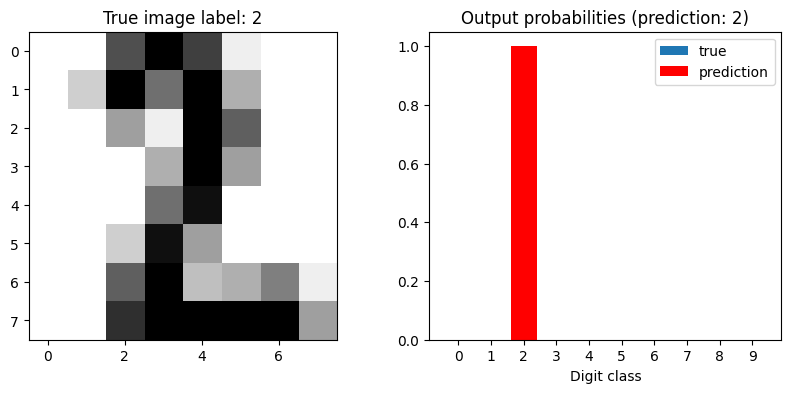

In [20]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

Now it's your turn to

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

Remember that you can use your `sigmoid` function inside your `dsigmoid` function.

Just like with our softmax function, we also want to make sure that we don't run into stability issues with our sigmoid function. We will use `np.clip` to ensure that the input to the sigmoid function is not too large or too small.

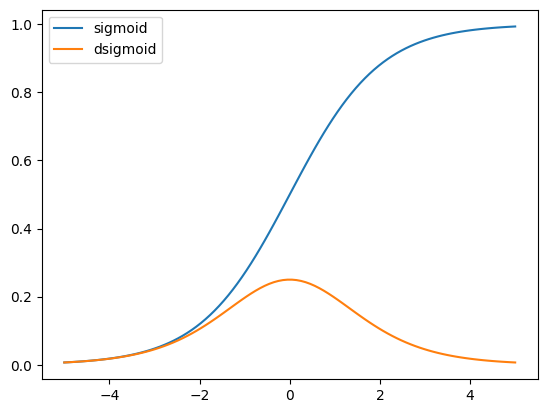

In [21]:
def sigmoid(X):
    # Clip X to prevent overflow or underflow
    X = np.clip(X, -500, 500) # This ensures that np.exp(X) doesn't overflow
    return 1 / (1 + np.exp(-X))


def dsigmoid(X):
    return sigmoid(X) * (1 - sigmoid(X))


x = np.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, dsigmoid(x), label='dsigmoid')
plt.legend(loc='best');

Now it's your turn to complete the neural network code, so that we can train it on the MNIST dataset.

Some parts have been completed for you already. Often, you'll be able to refer back to the code from the previous section to help you complete the code in this section.

In [22]:
class NeuralNet():
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):
        # Initializes the weights with random numbers
        self.W_h = np.random.uniform(size=(input_size, hidden_size),
                                     high=0.1, low=-0.1)
        self.b_h = np.random.uniform(size=hidden_size,
                                     high=0.1, low=-0.1)
        self.W_o = np.random.uniform(size=(hidden_size, output_size),
                                     high=0.1, low=-0.1)
        self.b_o = np.random.uniform(size=output_size,
                                     high=0.1, low=-0.1)

        # Store the input size, hidden size and output size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

    def forward_hidden(self, X):
        # Compute the linear combination of the input and weights
        self.Z_h = np.dot(X, self.W_h) + self.b_h

        # Apply the sigmoid activation function
        return sigmoid(self.Z_h)

    def forward_output(self, H):
        # Compute the linear combination of the hidden layer activation and weights
        self.Z_o = np.dot(H, self.W_o) + self.b_o

        # Apply the sigmoid activation function
        return sigmoid(self.Z_o)

    def forward(self, X):
        # Compute the forward activations of the hidden and output layers
        H = self.forward_hidden(X)
        Y = self.forward_output(H)

        return Y

    def loss(self, X, y):
        y_onehot = one_hot(self.output_size, y.astype(int))
        y_pred = self.forward(X)
        return nll(y_onehot, y_pred)

    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        # Compute the error at the output layer
        error_o = y_pred - y_true

        # Compute the gradient of the loss with respect to W_o and b_o
        grad_W_o = np.dot(self.Z_h.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)

        # Compute the error at the hidden layer
        error_h = np.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h)

        # Compute the gradient of the loss with respect to W_h and b_h
        grad_W_h = np.dot(X.T, error_h)
        grad_b_h = np.sum(error_h, axis=0)

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        # Ensure x is 2D
        x = x[np.newaxis, :]
        # Compute the gradient for the sample and update the weights
        grads = self.grad_loss(x, y)
    
        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]
        
    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)
    
# Raise an exception if you try to run this cell without having implemented the NeuralNet class
nn = NeuralNet(input_size=64, hidden_size=32, output_size=10)
try:
    assert(nn.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(nn.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the NeuralNet class.")

Once the code is written, we can test our model on a single sample:

In [23]:
n_hidden = 10
model = NeuralNet(n_features, n_hidden, n_classes)

In [24]:
model.loss(X_train, y_train)

1050.025871405889

In [25]:
model.accuracy(X_train, y_train)

0.09757694826457106

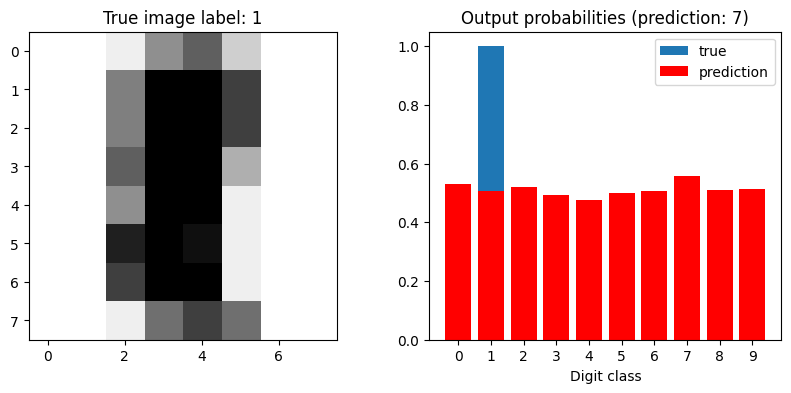

In [26]:
plot_prediction(model, sample_idx=5)

And now it's time to train!

In [27]:
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.001) #can try diff amounts?

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 1050.02587, train acc: 0.098, test acc: 0.089
Epoch #1, train loss: 3350.28966, train acc: 0.209, test acc: 0.185
Epoch #2, train loss: 3262.51580, train acc: 0.246, test acc: 0.230
Epoch #3, train loss: 2638.46360, train acc: 0.426, test acc: 0.407
Epoch #4, train loss: 2225.21276, train acc: 0.519, test acc: 0.522
Epoch #5, train loss: 1965.68365, train acc: 0.655, test acc: 0.600
Epoch #6, train loss: 1801.16048, train acc: 0.684, test acc: 0.626
Epoch #7, train loss: 1745.22112, train acc: 0.720, test acc: 0.644
Epoch #8, train loss: 1670.04076, train acc: 0.752, test acc: 0.696
Epoch #9, train loss: 1615.58164, train acc: 0.760, test acc: 0.715
Epoch #10, train loss: 1448.72787, train acc: 0.767, test acc: 0.715
Epoch #11, train loss: 1358.32051, train acc: 0.766, test acc: 0.715
Epoch #12, train loss: 1268.30633, train acc: 0.776, test acc: 0.711
Epoch #13, train loss: 1196.75961, train acc: 0.791, test acc: 0.730
Epoch #14, train loss: 1029.80221, train 

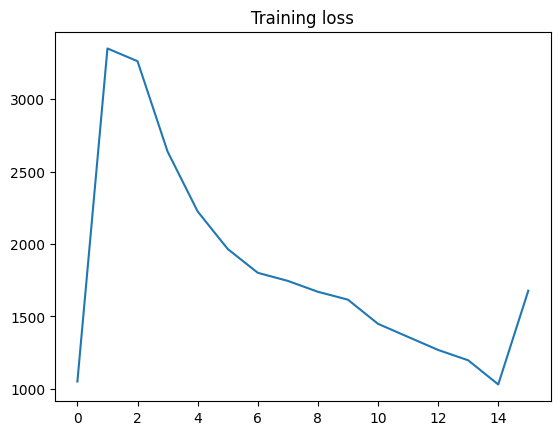

In [28]:
plt.plot(losses)
plt.title("Training loss");

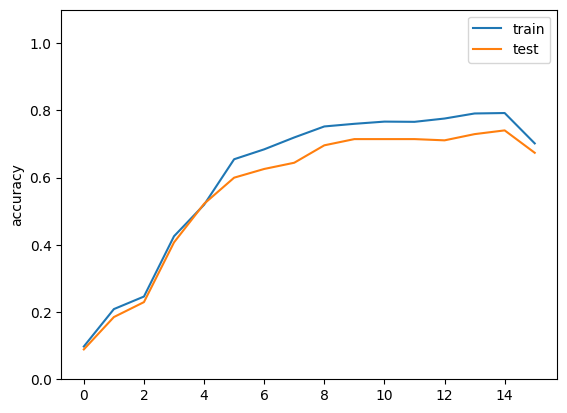

In [29]:
plt.plot(accuracies, label='train')
plt.plot(accuracies_test, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

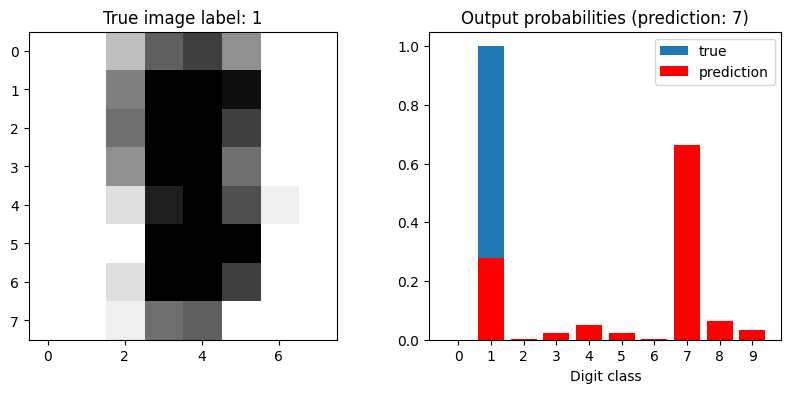

In [30]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use numpy to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

Highest test loss: 5.97284
True value: 8   Loss Value: 4.3189713558205
True value: 5   Loss Value: 4.605624098840042
True value: 9   Loss Value: 4.88859089129021
True value: 5   Loss Value: 4.911273271432104
True value: 5   Loss Value: 5.972839174962808


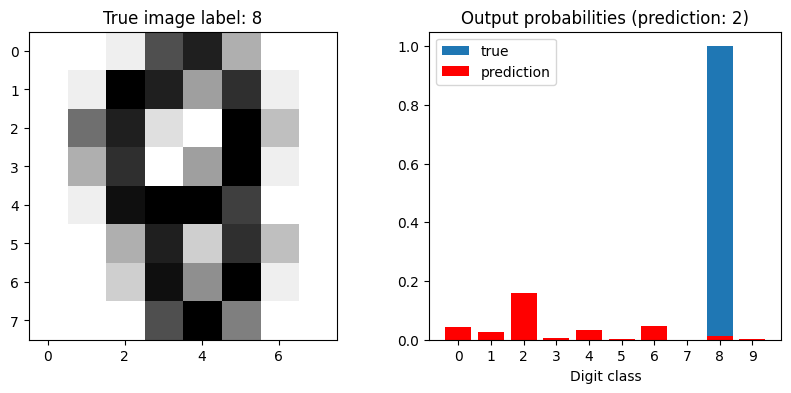

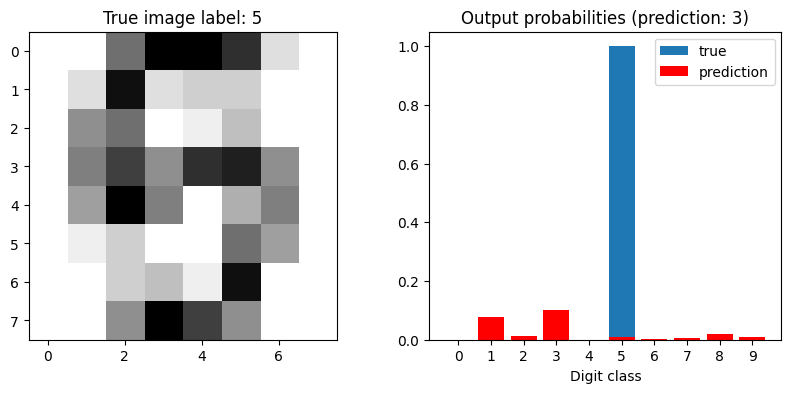

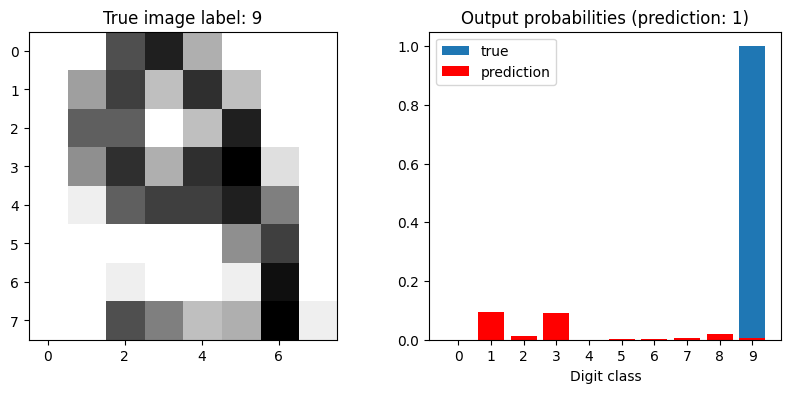

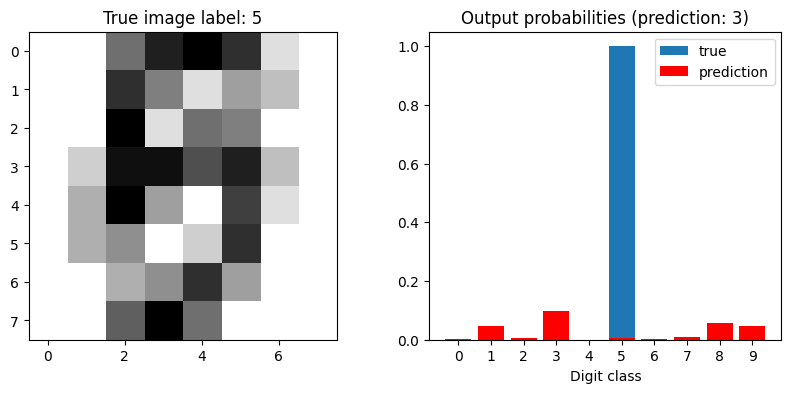

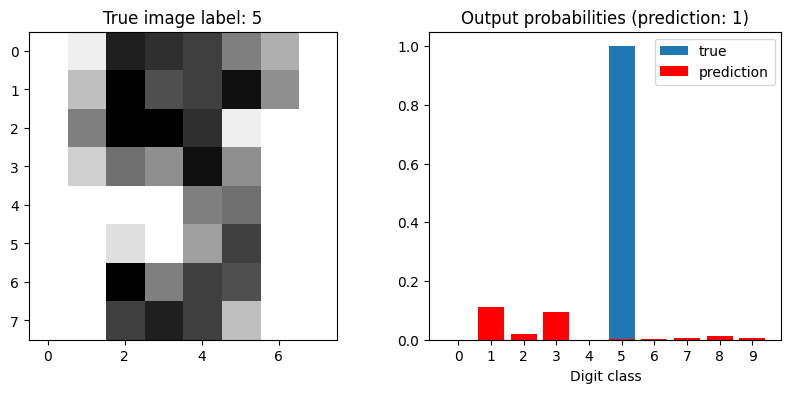

In [ ]:
# Your code here

#Compute loss values for the test set, and find the highest losses
test_losses = []
for x, y in zip(X_test, y_test):
    test_losses.append(model.loss(x, y))
print("Highest test loss: %0.5f" % np.max(test_losses))

#Find the indexes of the 5 highest loss values, add them to worst_5_losses variable 
worst_5_losses = np.argsort(test_losses)[-5:]
#worst_5_losses


#Write loop to print out each value, as well as the plot_prediction for each.
for i in worst_5_losses:
    print(f"True value: " + str(y_test[i]) + f"   Loss Value: " + str(test_losses[i])) #Pull the true value from y_test and actual loss value from test_losses.
    plot_prediction(model, sample_idx=i) #Use plot_prediction, but the worst index value.

#QUESTION: Would I have done any better?
# *Results are returned in descending order
#   5th Worst - Definitely would have done better, it's quite clear to be an 8.
#   4th Worst - Tracing the darkest lines would imply that it's a 5, but the darker grey lines could imply that it's actually 6, 8, or 9. 
            #However, it appears that the predicions are leaning towards 1 and 3 instead. I would still say I would be better.
#   3rd Worst - Similarly, the darkest lines would imply that it's a 3 or 9. The prediction weights aren't too far off from what I would guess, minus 
            #the confidence of it being 1. Aside from that, I could definitely misinterpret this.
#   2nd Worst - I would definitely struggle with this one, and can agree with the prediction spread, with the exception of 1. It could definitely
            #be almost any value except 1, 4, and 7.
#   The Worst - This is also a tough one, where it could be several values. I wouldn't be confident at all for guessing this one - Can definitely understand why the loss is so high.
#Overall for these cases, Iv'e noticed that the prediction values for 1 are quite high which I wouldn't even consider them as potential answers.
#It could also be the case where I read and write 1s differently though.



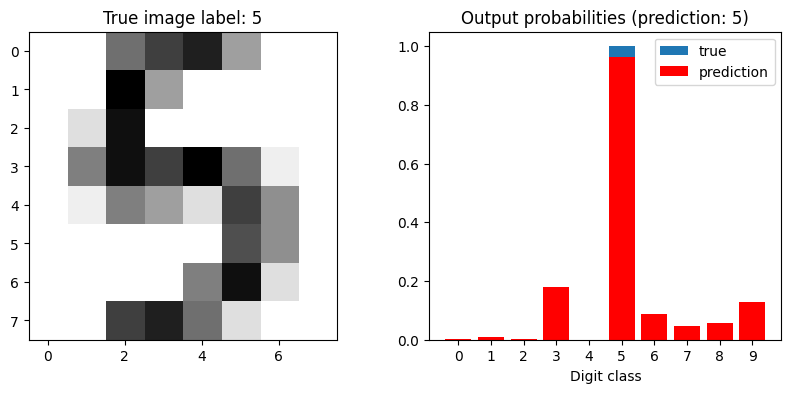

In [42]:
plot_prediction(model, sample_idx = 6)

### Hyper parameters settings

- Experiment with different hyperparameters:
  - learning rate,
  - size of hidden layer,
  - implement the support for a second hidden layer.
  - What is the best test accuracy you can get?

In [ ]:
# Your code here

#LEARNING RATE - 0.1
#Previously, learning_rate was was to 0.001.
for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.01)   #updated to 0.01

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

#OBSERVATIONS
#   Loss is slowly seeinc decrease, accuracies are not changing.

Epoch #1, train loss: 4009.33323, train acc: 0.100, test acc: 0.104
Epoch #2, train loss: 4009.32446, train acc: 0.100, test acc: 0.104
Epoch #3, train loss: 4009.31552, train acc: 0.100, test acc: 0.104
Epoch #4, train loss: 4009.30640, train acc: 0.100, test acc: 0.104
Epoch #5, train loss: 4009.29710, train acc: 0.100, test acc: 0.104
Epoch #6, train loss: 4009.28762, train acc: 0.100, test acc: 0.104
Epoch #7, train loss: 4009.27795, train acc: 0.100, test acc: 0.104
Epoch #8, train loss: 4009.26810, train acc: 0.100, test acc: 0.104
Epoch #9, train loss: 4009.25805, train acc: 0.100, test acc: 0.104
Epoch #10, train loss: 4009.24782, train acc: 0.100, test acc: 0.104
Epoch #11, train loss: 4009.23739, train acc: 0.100, test acc: 0.104
Epoch #12, train loss: 4009.22676, train acc: 0.100, test acc: 0.104
Epoch #13, train loss: 4009.21593, train acc: 0.100, test acc: 0.104
Epoch #14, train loss: 4009.20491, train acc: 0.100, test acc: 0.104
Epoch #15, train loss: 4009.19367, train ac

In [ ]:
#LEARNING RATE - 0.0001
#Previously, learning_rate was was to 0.001.
for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.0001)   #updated to 0.0001

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))
    
#OBSERVATIONS
#   Changes are miniscule, appears to have no change after epoch 10.

Epoch #1, train loss: 3629.10811, train acc: 0.102, test acc: 0.089
Epoch #2, train loss: 3533.49107, train acc: 0.109, test acc: 0.063
Epoch #3, train loss: 3521.00804, train acc: 0.109, test acc: 0.063
Epoch #4, train loss: 3519.48862, train acc: 0.109, test acc: 0.063
Epoch #5, train loss: 3519.30074, train acc: 0.109, test acc: 0.063
Epoch #6, train loss: 3519.27690, train acc: 0.109, test acc: 0.063
Epoch #7, train loss: 3519.27379, train acc: 0.109, test acc: 0.063
Epoch #8, train loss: 3519.27338, train acc: 0.109, test acc: 0.063
Epoch #9, train loss: 3519.27332, train acc: 0.109, test acc: 0.063
Epoch #10, train loss: 3519.27331, train acc: 0.109, test acc: 0.063
Epoch #11, train loss: 3519.27331, train acc: 0.109, test acc: 0.063
Epoch #12, train loss: 3519.27331, train acc: 0.109, test acc: 0.063
Epoch #13, train loss: 3519.27331, train acc: 0.109, test acc: 0.063
Epoch #14, train loss: 3519.27331, train acc: 0.109, test acc: 0.063
Epoch #15, train loss: 3519.27331, train ac

In [ ]:
#HIDDEN LAYER - 1

#From earlier, updating the n_hidden parameter, and recreating the model with the updated number of hidden layers. 
# Previously, n_hidden it was set to 10.
n_hidden = 1
model = NeuralNet(n_features, n_hidden, n_classes)

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.001)   #updated to 0.0001

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))
    
#OBSERVATIONS
#   The model actually appears to be getting worse, as the losses increased after each epoch, almost doubling by the last epoch.
#   The accuracies have not been significantly changing at all after each epoch run.


Epoch #1, train loss: 3056.72187, train acc: 0.100, test acc: 0.104
Epoch #2, train loss: 3426.99480, train acc: 0.100, test acc: 0.104
Epoch #3, train loss: 3500.26149, train acc: 0.100, test acc: 0.104
Epoch #4, train loss: 3516.08448, train acc: 0.100, test acc: 0.104
Epoch #5, train loss: 3519.70465, train acc: 0.100, test acc: 0.104
Epoch #6, train loss: 3520.66665, train acc: 0.100, test acc: 0.104
Epoch #7, train loss: 3521.06461, train acc: 0.100, test acc: 0.104
Epoch #8, train loss: 3521.36589, train acc: 0.100, test acc: 0.104
Epoch #9, train loss: 3521.61705, train acc: 0.100, test acc: 0.104
Epoch #10, train loss: 3521.07595, train acc: 0.100, test acc: 0.104
Epoch #11, train loss: 3492.62681, train acc: 0.100, test acc: 0.104
Epoch #12, train loss: 3468.55715, train acc: 0.100, test acc: 0.104
Epoch #13, train loss: 3432.28802, train acc: 0.101, test acc: 0.104
Epoch #14, train loss: 3402.14779, train acc: 0.100, test acc: 0.104
Epoch #15, train loss: 3383.20232, train ac

In [ ]:
#HIDDEN LAYER - 100

#From earlier, updating the n_hidden parameter, and recreating the model with the updated number of hidden layers. 
# Previously, n_hidden it was set to 10.
n_hidden = 100
model = NeuralNet(n_features, n_hidden, n_classes)

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.001)   #updated to 0.0001

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))
    
#OBSERVATIONS
#   Unlike only having 1 hidden layer, having more hidden layers appears to be training the model quite well.
#   The losses are decreasing and accuracies are increasing after each epoch.
#   By the final epoch, the accuracy scores are quite high.

Epoch #1, train loss: 1225.26836, train acc: 0.875, test acc: 0.856
Epoch #2, train loss: 734.33318, train acc: 0.928, test acc: 0.911
Epoch #3, train loss: 531.71423, train acc: 0.950, test acc: 0.930
Epoch #4, train loss: 426.57429, train acc: 0.961, test acc: 0.944
Epoch #5, train loss: 361.74060, train acc: 0.965, test acc: 0.952
Epoch #6, train loss: 317.06713, train acc: 0.970, test acc: 0.952
Epoch #7, train loss: 283.72199, train acc: 0.975, test acc: 0.956
Epoch #8, train loss: 257.41802, train acc: 0.976, test acc: 0.956
Epoch #9, train loss: 235.86613, train acc: 0.979, test acc: 0.959
Epoch #10, train loss: 217.72022, train acc: 0.981, test acc: 0.963
Epoch #11, train loss: 202.11705, train acc: 0.982, test acc: 0.967
Epoch #12, train loss: 188.47405, train acc: 0.983, test acc: 0.967
Epoch #13, train loss: 176.39136, train acc: 0.984, test acc: 0.967
Epoch #14, train loss: 165.59305, train acc: 0.985, test acc: 0.970
Epoch #15, train loss: 155.88614, train acc: 0.987, test

In [ ]:
#HIDDEN SECOND LAYER

#Need to change NeuralNet class to have the extra layer.
#Previously using h and o to indicate hidden and output
#   Now will use h1 for hidden layer 1, h2 for hidden layer 2, and o for output
#   Will also need to add additional steps for the hidden layer2 (ex. forward_hidden becomes forward_hidden1 and forward_hidden2)

class NeuralNet():
    """MLP with 2 hidden layers with a sigmoid activation"""

    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        # Initializes the weights with random numbers
        self.W_h1 = np.random.uniform(size=(input_size, hidden_size1),
                                     high=0.1, low=-0.1)
        self.b_h1 = np.random.uniform(size=hidden_size1,
                                     high=0.1, low=-0.1)
        
        self.W_h2 = np.random.uniform(size=(hidden_size1, hidden_size2),
                                     high=0.1, low=-0.1)
        self.b_h2 = np.random.uniform(size=hidden_size2,
                                     high=0.1, low=-0.1)


        self.W_o = np.random.uniform(size=(hidden_size2, output_size),
                                     high=0.1, low=-0.1)
        self.b_o = np.random.uniform(size=output_size,
                                     high=0.1, low=-0.1)

        # Store the input size, hidden size and output size
        self.input_size = input_size
        self.hidden_size1 = hidden_size1
        self.hidden_size2 = hidden_size2
        self.output_size = output_size

    def forward_hidden1(self, X):
        # Compute the linear combination of the input and weights
        self.Z_h1 = np.dot(X, self.W_h1) + self.b_h1

        # Apply the sigmoid activation function
        return sigmoid(self.Z_h1)
    


    #Since there is a new hidden layer, cannot just use H, will need to use H1 and H2 as parameters
    def forward_hidden2(self, H1):
        # Compute the linear combination of the input and weights
        self.Z_h2 = np.dot(H1, self.W_h2) + self.b_h2

        # Apply the sigmoid activation function
        return sigmoid(self.Z_h2)


    #Output will use output from H2, instead of just H cause of the additional layer.

    def forward_output(self, H2):
        # Compute the linear combination of the hidden layer activation and weights
        self.Z_o = np.dot(H2, self.W_o) + self.b_o

        # Apply the sigmoid activation function
        return sigmoid(self.Z_o)

    def forward(self, X):
        # Compute the forward activations of the hidden and output layers
        H1 = self.forward_hidden1(X)
        H2 = self.forward_hidden2(H1)
        Y = self.forward_output(H2)

        return Y

    def loss(self, X, y):
        y_onehot = one_hot(self.output_size, y.astype(int))
        y_pred = self.forward(X)
        return nll(y_onehot, y_pred)

    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        # Compute the error at the output layer
        error_o = y_pred - y_true

        # Compute the gradient of the loss with respect to W_o and b_o
        grad_W_o = np.dot(self.Z_h2.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)

        # Compute the error at the hidden layer 2
        error_h2 = np.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h2)

        # Compute the gradient of the loss with respect to W_h2 and b_h2
        grad_W_h2 = np.dot(self.Z_h1.T, error_h2)
        grad_b_h2 = np.sum(error_h2, axis=0)


        # Compute the error at the hidden layer 1
        error_h1 = np.dot(error_h2, self.W_h2.T) * dsigmoid(self.Z_h1)

        # Compute the gradient of the loss with respect to W_h1 and b_h1
        grad_W_h1 = np.dot(X.T, error_h1)
        grad_b_h1 = np.sum(error_h1, axis=0)


        return {"W_h1": grad_W_h1, "b_h1": grad_b_h1, "W_h2": grad_W_h2, "b_h2": grad_b_h2, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        # Ensure x is 2D
        x = x[np.newaxis, :]
        # Compute the gradient for the sample and update the weights
        grads = self.grad_loss(x, y)
    
        self.W_h1 -= learning_rate * grads["W_h1"]
        self.b_h1 -= learning_rate * grads["b_h1"]
        self.W_h2 -= learning_rate * grads["W_h2"]
        self.b_h2 -= learning_rate * grads["b_h2"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]
        
    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)
    
# Raise an exception if you try to run this cell without having implemented the NeuralNet class
nn = NeuralNet(input_size=64, hidden_size1=32, hidden_size2=20, output_size=10) #Now takes two hidden_size inputs
try:
    assert(nn.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(nn.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the NeuralNet class.")




#Running the model again with additional hidden layer. 
#   Providing the inputs:
n_hidden1 = 100
n_hidden2 = 50
model = NeuralNet(n_features, n_hidden1, n_hidden2, n_classes)

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.001)   #updated to 0.0001

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))
    
#OBSERVATIONS:
#THe model is improving with successive epochs, but still runs worse relative to just one hidden layer set to 100.
#   However by the final epoch, have good accuracy (still worse relatively)
#   The loss is still significantly higher (over 4 times)


Epoch #1, train loss: 3485.00217, train acc: 0.109, test acc: 0.063
Epoch #2, train loss: 3477.15614, train acc: 0.109, test acc: 0.063
Epoch #3, train loss: 3410.46753, train acc: 0.194, test acc: 0.159
Epoch #4, train loss: 3217.10545, train acc: 0.323, test acc: 0.289
Epoch #5, train loss: 2799.46239, train acc: 0.384, test acc: 0.352
Epoch #6, train loss: 2378.81064, train acc: 0.587, test acc: 0.541
Epoch #7, train loss: 2066.39419, train acc: 0.711, test acc: 0.648
Epoch #8, train loss: 1775.42729, train acc: 0.778, test acc: 0.719
Epoch #9, train loss: 1492.88701, train acc: 0.810, test acc: 0.770
Epoch #10, train loss: 1267.88547, train acc: 0.837, test acc: 0.807
Epoch #11, train loss: 1093.97482, train acc: 0.866, test acc: 0.837
Epoch #12, train loss: 952.73460, train acc: 0.892, test acc: 0.867
Epoch #13, train loss: 832.08704, train acc: 0.909, test acc: 0.896
Epoch #14, train loss: 725.30309, train acc: 0.932, test acc: 0.911
Epoch #15, train loss: 630.52108, train acc: 0

In [ ]:
#What is the best test accuracy you can get?

#From the following tests:
#   1. Increasing learning Rate to 0.1
#   2. Decreasing learning Rate to 0.0001
#   3. Setting Hidden Layer to 1
#   4. Setting Hidden Layer to 100
#   5. Adding second hidden layer, setting hidden layer1 to 100 and hidden layer2 to 50

# We see the best test accuracy from the 4th test: having a single hidden layer with a size of 100, with a value of 0.97.